<a href="https://colab.research.google.com/github/DiyaGhorpade/Internship-Fingerprint-Recognition/blob/main/fingerprint_classification_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# Fingerprint Classification with Ensemble Modeling - Final Enhanced Version
# Combines EfficientNet and InceptionV3 with advanced augmentation and training techniques.
# Complete Implementation for Google Colab.

# ============================================
# SECTION 1: INITIAL SETUP AND IMPORTS
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
# Import both model architectures
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
# Import specific preprocessing functions for each model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

# For evaluation
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import cv2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# ============================================
# SECTION 2: MOUNT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Update this path to match your Google Drive structure
BASE_PATH = '/content/drive/MyDrive/NISTDB4_RAW'  # Adjust this path as needed

# Define paths
TRAIN_PATH = os.path.join(BASE_PATH, 'train_set')
VAL_PATH = os.path.join(BASE_PATH, 'val_set')
TEST_PATH = os.path.join(BASE_PATH, 'test_set')

# Verify paths exist
print("Checking dataset paths...")
for path_name, path in [("Train", TRAIN_PATH), ("Validation", VAL_PATH), ("Test", TEST_PATH)]:
    if os.path.exists(path):
        print(f"✓ {path_name} path exists: {path}")
    else:
        print(f"✗ {path_name} path NOT found: {path}")

# ============================================
# SECTION 3: ENHANCED CONFIGURATION
# ============================================

# Model configuration
IMG_SIZE = 224
BATCH_SIZE = 32
INITIAL_EPOCHS = 25  # Increased epochs for more thorough training
FINE_TUNE_EPOCHS = 20
NUM_CLASSES = 3

# Create directories for saving results
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)


# ============================================
# SECTION 4: SMART AUGMENTATION FUNCTIONS
# ============================================

def random_cutout(image, min_holes=1, max_holes=5, min_size=0.1, max_size=0.25):
    """
    Applies random cutout (erasing) to an image.
    This is applied after standard augmentation.
    """
    # This function now receives and returns a numpy array directly
    h, w, _ = image.shape

    for _ in range(np.random.randint(min_holes, max_holes + 1)):
        hole_h = int(h * np.random.uniform(min_size, max_size))
        hole_w = int(w * np.random.uniform(min_size, max_size))
        y1 = np.random.randint(0, h - hole_h)
        x1 = np.random.randint(0, w - hole_w)
        y2 = y1 + hole_h
        x2 = x1 + hole_w
        image[y1:y2, x1:x2, :] = 0  # Fill with black

    return image

def random_gaussian_blur(image, max_kernel_size=5):
    """
    Applies Gaussian Blur with a random kernel size.
    """
    # This function now receives and returns a numpy array directly
    kernel_size = np.random.randint(1, max_kernel_size + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1 # Kernel must be odd
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def augment_image(image):
    """
    Wrapper function to apply advanced augmentations with a certain probability.
    This function now uses NumPy/OpenCV logic exclusively.
    """
    # Apply Blur with 30% probability using numpy's random function
    if np.random.rand() < 0.3:
        image = random_gaussian_blur(image)

    # Apply Cutout with 40% probability using numpy's random function
    if np.random.rand() < 0.4:
        image = random_cutout(image)

    # The .set_shape() call is removed as we are dealing with numpy arrays here.
    return image

# ============================================
# SECTION 5: ENHANCED DATA GENERATORS
# ============================================

# Training data generator with standard and advanced augmentations
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    # We will apply model-specific preprocessing later
    preprocessing_function=augment_image # Apply our smart augmentations
)

# Validation and test generators (no augmentation)
val_test_datagen = ImageDataGenerator() # Preprocessing will be handled inside model

# Create generators
print("\nCreating data generators...")

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Identify loop and arc indices
loop_class_index = train_generator.class_indices.get('class3_loop', -1) # FIX: Changed to lowercase 'l'
arc_class_index = train_generator.class_indices.get('class1_arc', -1)   # FIX: Changed to lowercase 'a'

# ============================================
# SECTION 6: CALCULATE CLASS WEIGHTS
# ============================================

labels = train_generator.labels
class_weights_array = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: w for i, w in enumerate(class_weights_array)}

# FIX: Added a check to ensure the key exists before trying to modify it
if loop_class_index != -1:
    class_weights[loop_class_index] *= 1.75 # Prioritize loop class
else:
    print("Warning: 'loop' class not found. Skipping priority weight.")


print("\nFinal Class Weights:")
for idx, weight in class_weights.items():
    class_name = [k for k,v in train_generator.class_indices.items() if v == idx][0]
    print(f"  {class_name}: {weight:.3f}")

# ============================================
# SECTION 7: MODEL BUILDING FUNCTIONS
# ============================================

# FIX: Define unique wrapper functions for each preprocessing step to solve saving/loading conflicts.
def eff_preprocess_wrapper(x):
    """Wrapper for the EfficientNet preprocessing function."""
    return efficientnet_preprocess(x)

def inc_preprocess_wrapper(x):
    """Wrapper for the InceptionV3 preprocessing function."""
    return inception_preprocess(x)


def build_model(model_name="efficientnet"):
    """
    Builds either an EfficientNetB0 or InceptionV3 model using the unique wrapper functions.
    """
    from tensorflow.keras.layers import Lambda

    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    if model_name == "efficientnet":
        # Use the unique wrapper function in the Lambda layer
        x = Lambda(eff_preprocess_wrapper, name='efficientnet_preprocessing')(inputs)
        base_model = EfficientNetB0(input_tensor=x, include_top=False, weights='imagenet')
    elif model_name == "inceptionv3":
        # Use the unique wrapper function in the Lambda layer
        x = Lambda(inc_preprocess_wrapper, name='inceptionv3_preprocessing')(inputs)
        base_model = InceptionV3(input_tensor=x, include_top=False, weights='imagenet')
    else:
        raise ValueError("model_name must be 'efficientnet' or 'inceptionv3'")

    base_model.trainable = False

    # Custom classification head
    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

# ============================================
# SECTION 8: GENERIC TRAINING FUNCTION
# ============================================

def train_model(model, base_model, model_name, train_gen, val_gen, c_weights, initial_epochs, fine_tune_epochs):
    """
    Generic function to train a model in two stages.
    """
    # --- Stage 1: Train Head ---
    print(f"\n{'='*50}\nTraining {model_name} - Stage 1: Classification Head\n{'='*50}")

    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks_s1 = [
        ModelCheckpoint(f'/content/models/best_model_{model_name}_s1.h5', monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    ]

    history_s1 = model.fit(train_gen, epochs=initial_epochs, validation_data=val_gen,
                           callbacks=callbacks_s1, class_weight=c_weights, verbose=1)

    # --- Stage 2: Fine-Tuning ---
    print(f"\n{'='*50}\nTraining {model_name} - Stage 2: Fine-Tuning\n{'='*50}")

    base_model.trainable = True
    fine_tune_at = int(len(base_model.layers) * 0.7)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks_s2 = [
        ModelCheckpoint(f'/content/models/best_model_{model_name}_s2_finetuned.h5', monitor='val_accuracy', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
    ]

    history_s2 = model.fit(train_gen, epochs=fine_tune_epochs, validation_data=val_gen,
                           callbacks=callbacks_s2, class_weight=c_weights, verbose=1)

    return history_s1, history_s2


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking dataset paths...
✓ Train path exists: /content/drive/MyDrive/NISTDB4_RAW/train_set
✓ Validation path exists: /content/drive/MyDrive/NISTDB4_RAW/val_set
✓ Test path exists: /content/drive/MyDrive/NISTDB4_RAW/test_set

Creating data generators...
Found 1559 images belonging to 3 classes.
Found 479 images belonging to 3 classes.
Found 225 images belonging to 3 classes.

Final Class Weights:
  class1_arc: 0.928
  class2_whorl: 0.930
  class3_loop: 2.067


In [58]:
# ============================================
# SECTION 9: TRAIN MODEL 1 - EFFICIENTNET
# ============================================

efficientnet_model, efficientnet_base = build_model("efficientnet")
hist_eff_s1, hist_eff_s2 = train_model(efficientnet_model, efficientnet_base, "efficientnet",
                                       train_generator, validation_generator, class_weights,
                                       INITIAL_EPOCHS, FINE_TUNE_EPOCHS)

# ============================================
# SECTION 10: TRAIN MODEL 2 - INCEPTIONV3
# ============================================

inception_model, inception_base = build_model("inceptionv3")
hist_inc_s1, hist_inc_s2 = train_model(inception_model, inception_base, "inceptionv3",
                                       train_generator, validation_generator, class_weights,
                                       INITIAL_EPOCHS, FINE_TUNE_EPOCHS)


Training efficientnet - Stage 1: Classification Head
Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.5156 - loss: 5.9835

49/49 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5171 - loss: 5.9754 - val_accuracy: 0.5240 - val_loss: 4.7076 - learning_rate: 0.0010
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 577ms/step - accuracy: 0.6718 - loss: 4.8088 - val_accuracy: 0.4092 - val_loss: 4.4950 - learning_rate: 0.0010
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.7091 - loss: 4.1664

49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 584ms/step - accuracy: 0.7092 - loss: 4.1645 - val_accuracy: 0.6284 - val_loss: 3.5783 - learning_rate: 0.0010
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.7222 - loss: 3.6639

49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 582ms/step - accuracy: 0.7221 - loss: 3.6629 - val_accuracy: 0.7140 - val_loss: 3.0777 - learning_rate: 0.0010
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.7248 - loss: 3.2668

49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 581ms/step - accuracy: 0.7251 - loss: 3.2651 - val_accuracy: 0.7307 - val_loss: 2.7317 - learning_rate: 0.0010
Epoch 6/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.7376 - loss: 2.8842

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 599ms/step - accuracy: 0.7004 - loss: 2.7941 - val_accuracy: 0.8100 - val_loss: 2.1801 - learning_rate: 0.0010
Epoch 8/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 593ms/step - accuracy: 0.6757 - loss: 2.5283 - val_accuracy: 0.7745 - val_loss: 1.9852 - learning_rate: 0.0010
Epoch 9/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 31s 624ms/step - accuracy: 0.6975 - loss: 2.2812 - val_accuracy: 0.8038 - val_loss: 1.7613 - learning_rate: 0.0010
Epoch 10/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.6740 - loss: 2.1189

49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 604ms/step - accuracy: 0.6739 - loss: 2.1180 - val_accuracy: 0.8205 - val_loss: 1.5438 - learning_rate: 0.0010
Epoch 11/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 591ms/step - accuracy: 0.7090 - loss: 1.8763 - val_accuracy: 0.7850 - val_loss: 1.4493 - learning_rate: 0.0010
Epoch 12/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 586ms/step - accuracy: 0.7055 - loss: 1.7504 - val_accuracy: 0.8017 - val_loss: 1.3088 - learning_rate: 0.0010
Epoch 13/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 590ms/step - accuracy: 0.7086 - loss: 1.6787 - val_accuracy: 0.7891 - val_loss: 1.2556 - learning_rate: 0.0010
Epoch 14/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.7084 - loss: 1.5985

49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 607ms/step - accuracy: 0.7082 - loss: 1.5981 - val_accuracy: 0.8539 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 15/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 583ms/step - accuracy: 0.6929 - loss: 1.5125 - val_accuracy: 0.7704 - val_loss: 1.1086 - learning_rate: 0.0010
Epoch 16/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 599ms/step - accuracy: 0.7055 - loss: 1.4119 - val_accuracy: 0.8142 - val_loss: 1.0055 - learning_rate: 0.0010
Epoch 17/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 588ms/step - accuracy: 0.6822 - loss: 1.3915 - val_accuracy: 0.8038 - val_loss: 0.9939 - learning_rate: 0.0010
Epoch 18/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 611ms/step - accuracy: 0.6992 - loss: 1.3444 - val_accuracy: 0.7912 - val_loss: 0.9815 - learning_rate: 0.0010
Epoch 19/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 598ms/step - accuracy: 0.7131 - loss: 1.2861 - val_accuracy: 0.8163 - val_loss: 0.8934 - learning_rate: 0.0010
Epoch 20/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 584ms/step - accuracy: 0.7204 - loss: 1.2164 

49/49 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5379 - loss: 1.6587 - val_accuracy: 0.7975 - val_loss: 0.8607 - learning_rate: 1.0000e-05
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 30s 595ms/step - accuracy: 0.6203 - loss: 1.4407 - val_accuracy: 0.7871 - val_loss: 0.8792 - learning_rate: 1.0000e-05
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 595ms/step - accuracy: 0.6399 - loss: 1.3941 - val_accuracy: 0.7933 - val_loss: 0.8692 - learning_rate: 1.0000e-05
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.6870 - loss: 1.2583
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 601ms/step - accuracy: 0.6871 - loss: 1.2580 - val_accuracy: 0.7891 - val_loss: 0.8715 - learning_rate: 1.0000e-05
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 596ms/step - accuracy: 0.6936 - loss: 1.2605 - val_accuracy: 0.7912 - val_loss: 0.8724 - learning_rate: 2.0000e-06
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6852 - los

49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 684ms/step - accuracy: 0.6852 - loss: 1.2726 - val_accuracy: 0.7996 - val_loss: 0.8656 - learning_rate: 2.0000e-06
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7014 - loss: 1.2420
Epoch 7: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 598ms/step - accuracy: 0.7016 - loss: 1.2414 - val_accuracy: 0.7975 - val_loss: 0.8658 - learning_rate: 2.0000e-06
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 1.



ENSEMBLE MODEL EVALUATION ON TEST SET
Loading models with custom objects...
✓ Models loaded successfully!

Generating predictions from both models...
8/8 ━━━━━━━━━━━━━━━━━━━━ 119s 16s/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step

ENSEMBLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

  class1_arc     0.9277    0.9506    0.9390        81
class2_whorl     0.9146    0.9259    0.9202        81
 class3_loop     0.8667    0.8254    0.8455        63

    accuracy                         0.9067       225
   macro avg     0.9030    0.9006    0.9016       225
weighted avg     0.9059    0.9067    0.9061       225


ENSEMBLE CONFUSION MATRIX


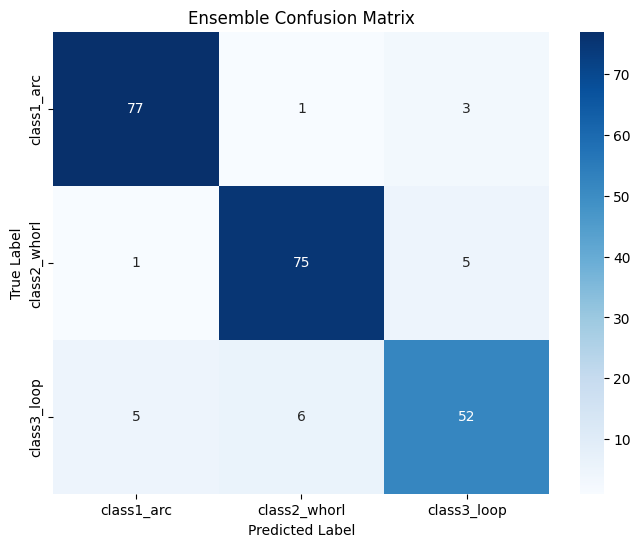

In [62]:
# ============================================
# SECTION 11: ENSEMBLE EVALUATION
# ============================================

print("\n" + "="*50)
print("ENSEMBLE MODEL EVALUATION ON TEST SET")
print("="*50)

# FIX: Create a custom_objects dictionary to map the saved function names
# to the actual Python functions. This is the definitive fix for the loading error.
custom_objects = {
    'eff_preprocess_wrapper': eff_preprocess_wrapper,
    'inc_preprocess_wrapper': inc_preprocess_wrapper
}

# Load best versions of both models using the custom_objects dictionary
print("Loading models with custom objects...")
best_eff_model = tf.keras.models.load_model(
    '/content/models/best_model_efficientnet_s2_finetuned.h5',
    custom_objects=custom_objects,
    compile=False
)
best_inc_model = tf.keras.models.load_model(
    '/content/models/best_model_inceptionv3_s2_finetuned.h5',
    custom_objects=custom_objects,
    compile=False
)
print("✓ Models loaded successfully!")


# Get predictions from both models
print("\nGenerating predictions from both models...")
predictions_eff = best_eff_model.predict(test_generator)
predictions_inc = best_inc_model.predict(test_generator)

# Average the predictions (Ensemble)
ensemble_predictions = (predictions_eff + predictions_inc) / 2
ensemble_predicted_classes = np.argmax(ensemble_predictions, axis=1)
true_classes = test_generator.classes
class_names = list(train_generator.class_indices.keys())

# --- Evaluate Ensemble Performance ---
print("\n" + "="*50)
print("ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
ensemble_report = classification_report(true_classes, ensemble_predicted_classes, target_names=class_names, digits=4)
print(ensemble_report)

print("\n" + "="*50)
print("ENSEMBLE CONFUSION MATRIX")
print("="*50)
ensemble_cm = confusion_matrix(true_classes, ensemble_predicted_classes)

# Plot ensemble confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ensemble_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Ensemble Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.savefig('/content/results/ensemble_confusion_matrix.png')
plt.show()

In [63]:
# ============================================
# SECTION 12: ENSEMBLE INFERENCE FUNCTIONS
# ============================================

def predict_fingerprint_ensemble(image_path, model_a, model_b):
    """
    Enhanced prediction using an ensemble of two models.
    Preprocessing is now handled inside the models, so no external enhancement is needed.
    """
    # Read the image and ensure it's in RGB format
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Models expect RGB

    # Resize to the model's expected input size
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Prepare a batch of 1 for prediction.
    # IMPORTANT: Do NOT apply any other preprocessing here.
    img_batch = np.expand_dims(img_resized, axis=0)

    # Get predictions from both models
    pred_a = model_a.predict(img_batch, verbose=0)
    pred_b = model_b.predict(img_batch, verbose=0)

    # Average the probabilities
    ensemble_pred = (pred_a + pred_b) / 2

    predicted_class_idx = np.argmax(ensemble_pred[0])
    confidence = ensemble_pred[0][predicted_class_idx]
    class_name = class_names[predicted_class_idx]

    result = {
        'predicted_class': class_name,
        'confidence': float(confidence),
        'all_probabilities': {class_names[i]: float(ensemble_pred[0][i]) for i in range(NUM_CLASSES)}
    }
    return result

print("\n✓ Ensemble inference function ready!")
print("\nExample usage:")
print("result = predict_fingerprint_ensemble('/path/to/image.png', best_eff_model, best_inc_model)")
print("print(result)")


✓ Ensemble inference function ready!

Example usage:
result = predict_fingerprint_ensemble('/path/to/image.png', best_eff_model, best_inc_model)
print(result)
